# <b><font color='saddlebrown'>Основы статистики_практикум</font></b>

### <b><font color='saddlebrown'>Как выбрать распределение</font></b>

| Ситуация                                                  | Вероятное распределение | 
| ----------------------------------------------------------| ----------------------- | 
| Количество событий за фиксированное время (звонки, заказы)| **Пуассоновское**       | 
| Количество успешных исходов в серии испытаний             | **Биномиальное**        |
| Время до следующего события (до отказа, до клика)         | **Экспоненциальное**    |
| Измеримые физические величины (рост, доход, время)        | **Нормальное**          | 
| Случайное равновероятное значение в диапазоне             | **Равномерное**         | 

### <b><font color='saddlebrown'>PMF и CDF</font></b>

<b> PMF - вероятность "точечного" события: </b><br>
- применяется только к дискретным распределениям
- показывает вероятность конкретного исхода

<b> CDF - сумма всех вероятностей до некоторой точки: </b><br>
- применяется и к дискретным, и к непрерывным распределениям 
- показывает вероятность того, что случайная величина ≤ заданного значения

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import plotly.express as px
from scipy import stats
from scipy.stats import binom


### <b><font color='saddlebrown'>Задача 1</font></b>
<i>Задача:</i>
Компания тестирует новую email-рассылку. Из 10 000 клиентов, каждому отправлено письмо. Известно, что вероятность перехода по ссылке — 3%.<br>
<i>Практические вопросы:</i>
- Какова вероятность, что кликнут ровно 400 человек?
- Какова вероятность, что кликнут не менее 350 человек?
- Постройте график биномиального распределения для данной задачи.

In [12]:
# Какова вероятность, что кликнут ровно 400 человек?

round(binom.pmf(k = 400, n = 10_000, p = 0.03),10)

np.float64(3.5e-09)

In [13]:
# Какова вероятность, что кликнут не менее 350 человек?

In [14]:
df2 = 1-binom.cdf(349,10000,0.03)
df2

np.float64(0.0022680139534446697)

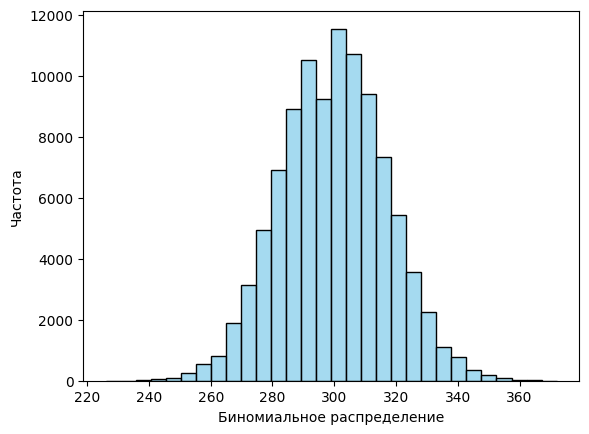

In [18]:
# Постройте график биномиального распределения для данной задачи
n = 10000 # количество испытаний
p = 0.03 # вероятность успеха
data_binom = binom.rvs(n = n, p = p, size = 100000)

# Построение графика распределения
ax = sns.histplot(data_binom, kde = False, color = 'skyblue', bins = 30)
ax.set(xlabel='Биномиальное распределение', ylabel = 'Частота')
plt.show()

### <b><font color='saddlebrown'>Задача 2</font></b>
<i>Задача:</i>
Оператор колл-центра получает в среднем 12 звонков в час.<br>
<i>Практические вопросы:</i>
- Какова вероятность получить 15 звонков за час?
- Какова вероятность, что за 30 минут будет не более 5 звонков?
- Построй гистограмму вероятностей для диапазона от 0 до 25 звонков.

In [19]:
from scipy.stats import poisson

# Какова вероятность получить 15 звонков за час?
poisson.pmf(k = 15, mu = 12)

np.float64(0.07239112014663847)

In [20]:
# Какова вероятность, что за 30 минут будет не более 5 звонков?
poisson.cdf(k = 4, mu = 6)

np.float64(0.2850565003166312)

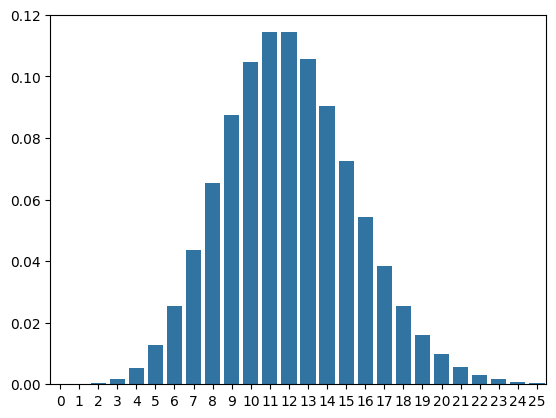

In [21]:
# Построй гистограмму вероятностей для диапазона от 0 до 25 звонков.
x = range(0,26)
y = poisson.pmf(k = x, mu =12)
sns.barplot(x = x, y = y)
plt.show()

### <b><font color='saddlebrown'>Задача 3</font></b>
Время обработки заявки в банке распределено нормально: среднее — 20 мин, стандартное отклонение — 4 мин.<br>
<i>Практические вопросы:</i>
- Какова вероятность, что заявка будет обработана за ≤ 15 минут?
- Какой процент заявок обрабатывается дольше 25 минут?
- Сгенерируйте 10000 случайных значений и постройте по ним гистограмму распределения.

In [4]:
from scipy.stats import norm
display(norm.cdf(x = 15, loc = 20, scale = 4))

# Какой процент заявок обрабатывается дольше 25 минут?
display(1-norm.cdf(x = 25, loc = 20, scale = 4))


np.float64(0.10564977366685535)

np.float64(0.10564977366685535)

array([19.95556959, 19.97805708, 27.64256896, ..., 21.79719627,
       18.87965397, 22.94778684], shape=(10000,))

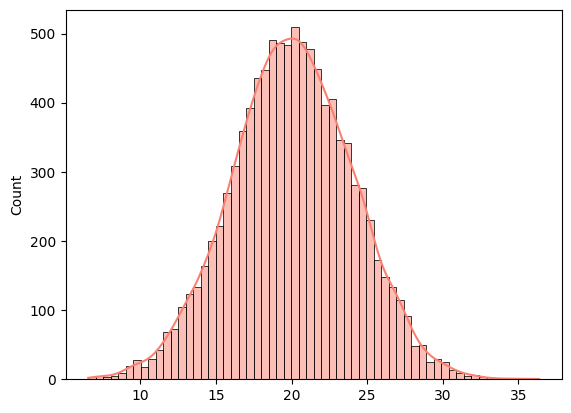

array([24.14481344, 22.25118071, 22.4647539 , ..., 18.62096307,
       23.83716356, 18.74078623], shape=(10000,))

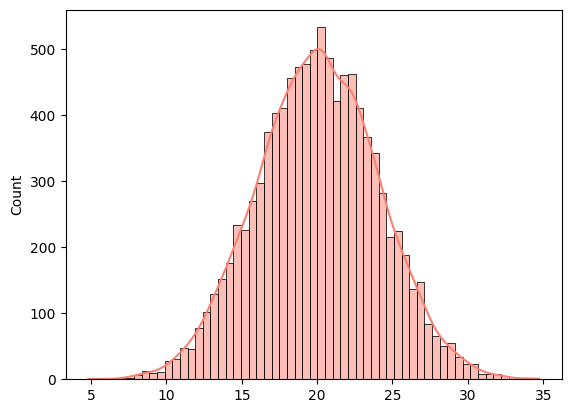

In [8]:
# Сгенерируйте 10000 случайных значений и постройте по ним гистограмму распределения.
data_norm_1 = np.random.normal(loc = 20, scale = 4, size = 10000)
display(data_norm_1)
sns.histplot(data_norm_1, kde = True, color = 'salmon')
plt.show()
data_norm = norm.rvs(loc = 20, scale = 4, size = 10000)
display(data_norm)
sns.histplot(data_norm, kde = True, color = 'salmon')
plt.show()


### <b><font color='saddlebrown'>Задача 4</font></b>
Среднее время между сбоями сервера — 5 часов.<br>
<i>Практические вопросы:</i>
- Какова вероятность, что следующий сбой произойдет раньше чем через 3 часа?
- Найдите медианное время между сбоями.
- Сгенерируйте выборку из 1000 наблюдений и оцените интенсивность λ.

In [18]:
from scipy.stats import expon
# Вероятность того, что следующий сбой произойдет раньше чем через 3 часа
mean_time = 5
lam = 1/mean_time
expon.cdf(x = 3, scale = 1/lam)


np.float64(0.4511883639059735)

In [19]:
# - Найдите медианное время между сбоями.
expon.median(scale = 1/lam)

np.float64(3.4657359027997265)

Оценка интенсивности λ: 0.19059243957637179


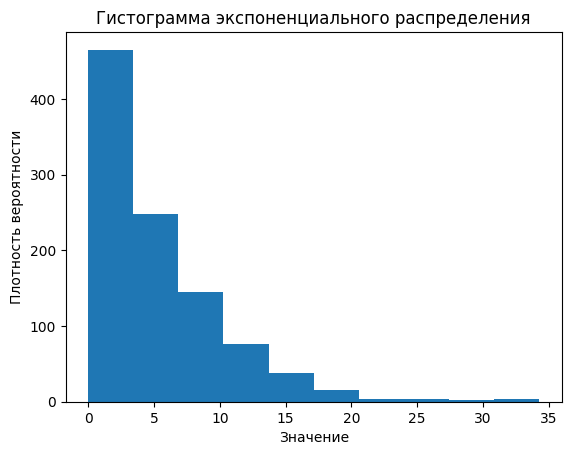

In [ ]:
# - Сгенерируйте выборку из 1000 наблюдений и оцените интенсивность λ.
data_exponential = expon.rvs(scale = 1/lam, size = 1000)
estimated_lambda = 1 / np.mean(data_exponential)
print(f"Оценка интенсивности λ: {estimated_lambda}")

plt.hist(data_exponential)
plt.title('Гистограмма экспоненциального распределения')
plt.xlabel('Значение')
plt.ylabel('Плотность вероятности')
plt.show()

### <b><font color='saddlebrown'>Задача 5</font></b>
Пользователь попадает на сайт, где баннеры показываются случайно. Время просмотра страницы равномерно распределено между 10 и 50 сек.<br>
<i>Практические вопросы:</i>
- Какова вероятность, что пользователь пробудет на странице более 40 сек?
- Найдите среднее и дисперсию.
- Сгенерируйте 1000 наблюдений и сравните гистограмму с теоретической плотностью.

In [31]:
from scipy.stats import uniform
uniform.cdf(40, 10, 40)


np.float64(0.75)

In [34]:
display(uniform.mean(loc = 10, scale = 40))
display(uniform.var(loc = 10, scale = 40))

np.float64(30.0)

np.float64(133.33333333333331)

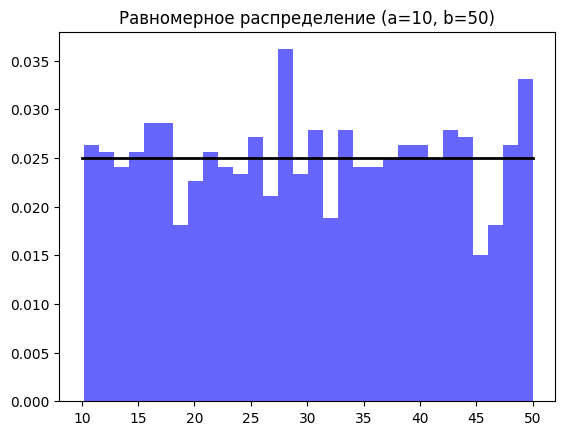

In [26]:
a = 10 # нижняя граница
b = 50 # верхняя граница

# Генерируем равномерно распределенные случайные величины
data_uniform = uniform.rvs(loc = a, scale = b - a, size = 1000)

# Построение графика распределения
plt.hist(data_uniform, bins = 30, density = True, alpha = 0.6, color = 'b')

# Построение графика PDF
x = np.linspace(a, b, 100)
p = uniform.pdf(x, loc = a, scale = b-a)
plt.plot(x, p, 'k', linewidth = 2)
plt.title("Равномерное распределение (a=10, b=50)")
plt.show()